In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [3]:
start = '2011-01-01'
end = '2024-01-01'
stock = 'RELIANCE.NS'
data = yf.download(stock, start, end)

/tmp/ipykernel_4604/3172886626.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed


In [4]:
data

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2011-01-03,216.135559,218.367354,215.521309,218.060222,10411256
2011-01-04,220.537750,221.111052,216.483678,217.036505,22021878
2011-01-05,220.271530,223.178999,219.083965,221.131475,25943243
2011-01-06,222.278091,223.465643,220.015585,220.721971,21763180
2011-01-07,218.142136,222.718336,216.626977,221.397686,17875107
...,...,...,...,...,...
2023-12-22,1273.102173,1280.968874,1264.466020,1270.397218,16541784
2023-12-26,1279.554443,1286.453333,1271.935784,1274.566338,7465664


In [5]:
data.columns

MultiIndex([( 'Close', 'RELIANCE.NS'),
            (  'High', 'RELIANCE.NS'),
            (   'Low', 'RELIANCE.NS'),
            (  'Open', 'RELIANCE.NS'),
            ('Volume', 'RELIANCE.NS')],
           names=['Price', 'Ticker'])

In [6]:
data.reset_index(inplace=True)

In [7]:
data

Price,Date,Close,High,Low,Open,Volume
Ticker,,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
0,2011-01-03,216.135559,218.367354,215.521309,218.060222,10411256
1,2011-01-04,220.537750,221.111052,216.483678,217.036505,22021878
2,2011-01-05,220.271530,223.178999,219.083965,221.131475,25943243
3,2011-01-06,222.278091,223.465643,220.015585,220.721971,21763180
4,2011-01-07,218.142136,222.718336,216.626977,221.397686,17875107
...,...,...,...,...,...,...
3199,2023-12-22,1273.102173,1280.968874,1264.466020,1270.397218,16541784
3200,2023-12-26,1279.554443,1286.453333,1271.935784,1274.566338,7465664
3201,2023-12-27,1283.922119,1290.399082,1277.097630,1281.514887,9204156


In [8]:
data.dropna(inplace = True)

In [9]:
data

Price,Date,Close,High,Low,Open,Volume
Ticker,,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
0,2011-01-03,216.135559,218.367354,215.521309,218.060222,10411256
1,2011-01-04,220.537750,221.111052,216.483678,217.036505,22021878
2,2011-01-05,220.271530,223.178999,219.083965,221.131475,25943243
3,2011-01-06,222.278091,223.465643,220.015585,220.721971,21763180
4,2011-01-07,218.142136,222.718336,216.626977,221.397686,17875107
...,...,...,...,...,...,...
3199,2023-12-22,1273.102173,1280.968874,1264.466020,1270.397218,16541784
3200,2023-12-26,1279.554443,1286.453333,1271.935784,1274.566338,7465664
3201,2023-12-27,1283.922119,1290.399082,1277.097630,1281.514887,9204156


In [41]:
ma_100_days = data.Close.rolling(100).mean()

Text(0, 0.5, 'Close Price')

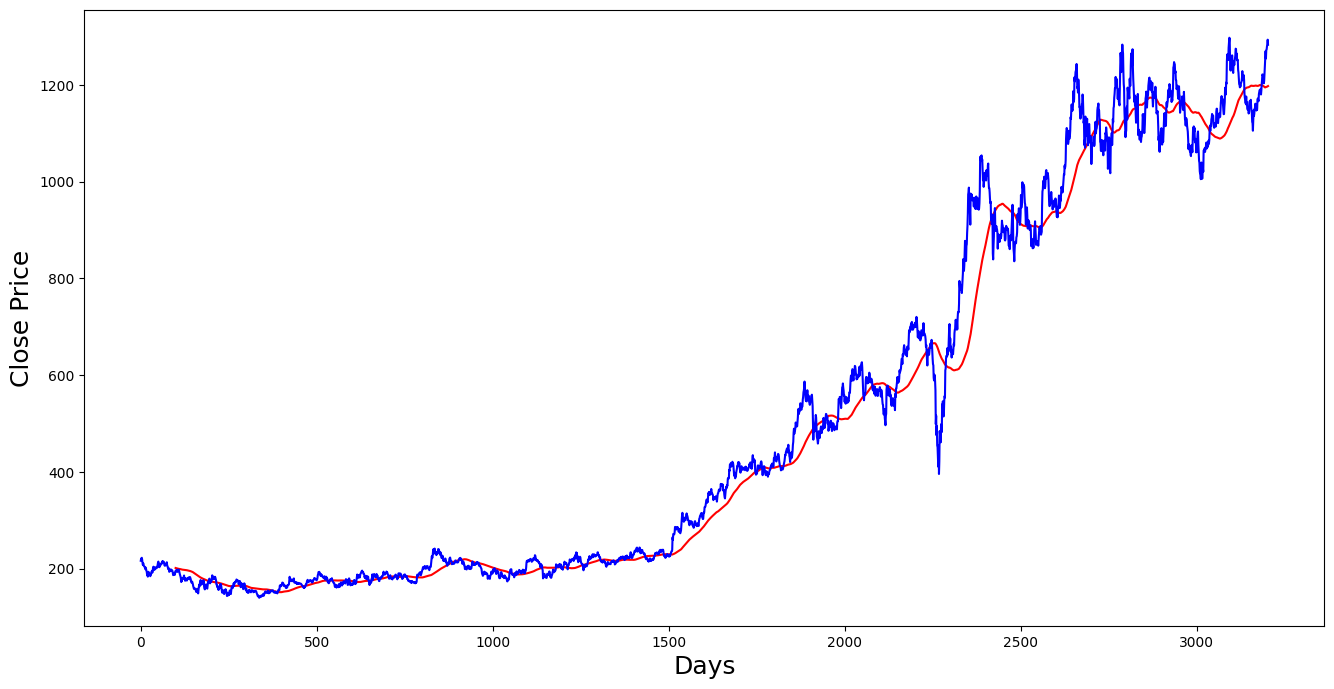

In [42]:
plt.figure(figsize=(16,8))
plt.plot(ma_100_days, 'r')
plt.plot(data.Close, 'b')
plt.xlabel('Days',fontsize=18)
plt.ylabel('Close Price',fontsize=18)

In [43]:
ma_200_days = data.Close.rolling(200).mean()

Text(0, 0.5, 'Close Price')

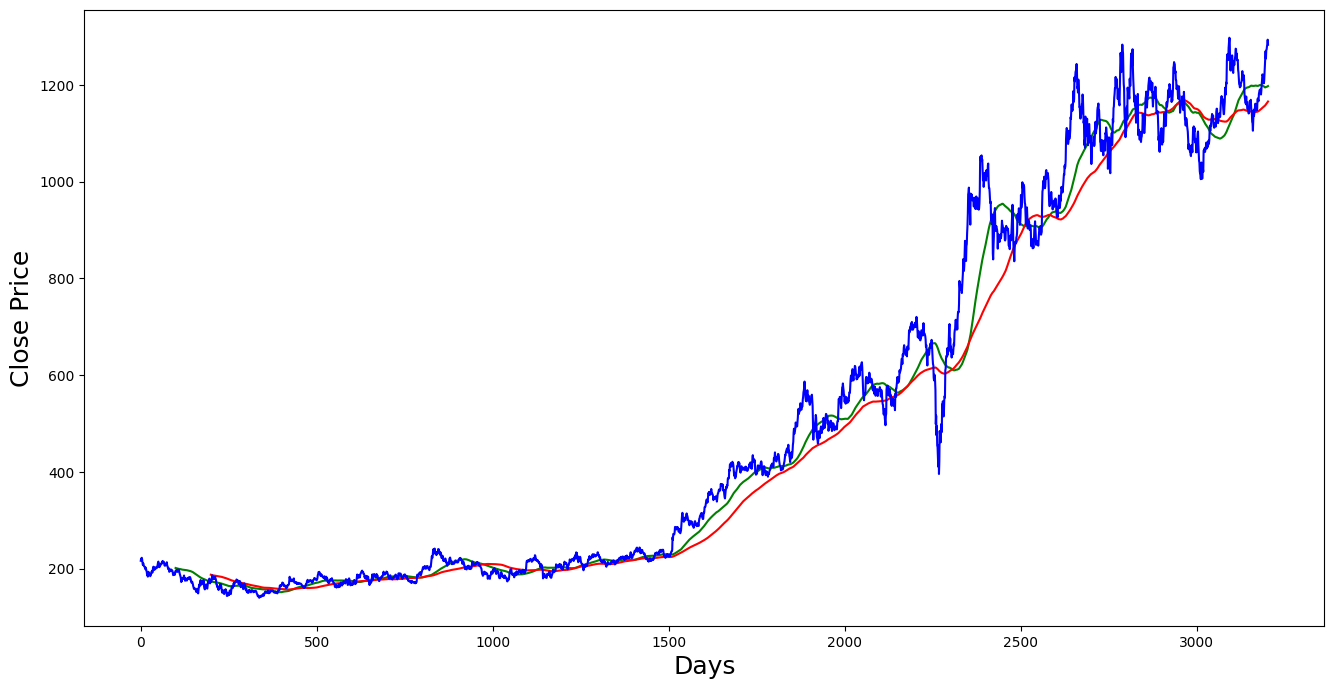

In [44]:
plt.figure(figsize=(16,8))
plt.plot(ma_100_days, 'g')
plt.plot(ma_200_days, 'r')
plt.plot(data.Close, 'b')
plt.xlabel('Days',fontsize=18)
plt.ylabel('Close Price',fontsize=18)

In [10]:
data_train = data[data['Date'].between('2011-01-01','2020-12-31')]

In [11]:
data_test = data[data['Date'].between('2021-01-01','2024-01-01')]

In [12]:
data_train

Price,Date,Close,High,Low,Open,Volume
Ticker,,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
0,2011-01-03,216.135559,218.367354,215.521309,218.060222,10411256
1,2011-01-04,220.537750,221.111052,216.483678,217.036505,22021878
2,2011-01-05,220.271530,223.178999,219.083965,221.131475,25943243
3,2011-01-06,222.278091,223.465643,220.015585,220.721971,21763180
4,2011-01-07,218.142136,222.718336,216.626977,221.397686,17875107
...,...,...,...,...,...,...
2458,2020-12-24,904.210022,906.318439,882.331935,882.830689,20776988
2459,2020-12-28,908.358887,915.024336,904.731419,909.900546,17221499
2460,2020-12-29,902.350891,912.439737,898.950103,910.943414,18611939


In [13]:
data_test

Price,Date,Close,High,Low,Open,Volume
Ticker,,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
2463,2021-01-01,901.194580,905.502145,898.700689,901.421259,10015175
2464,2021-01-04,902.713684,906.363760,892.352763,904.640758,24513534
2465,2021-01-05,891.491211,899.426244,886.911511,892.806130,24123091
2466,2021-01-06,867.980774,891.445793,863.854552,891.400457,46401468
2467,2021-01-07,866.575134,881.923778,863.854564,870.814696,32325918
...,...,...,...,...,...,...
3199,2023-12-22,1273.102173,1280.968874,1264.466020,1270.397218,16541784
3200,2023-12-26,1279.554443,1286.453333,1271.935784,1274.566338,7465664
3201,2023-12-27,1283.922119,1290.399082,1277.097630,1281.514887,9204156


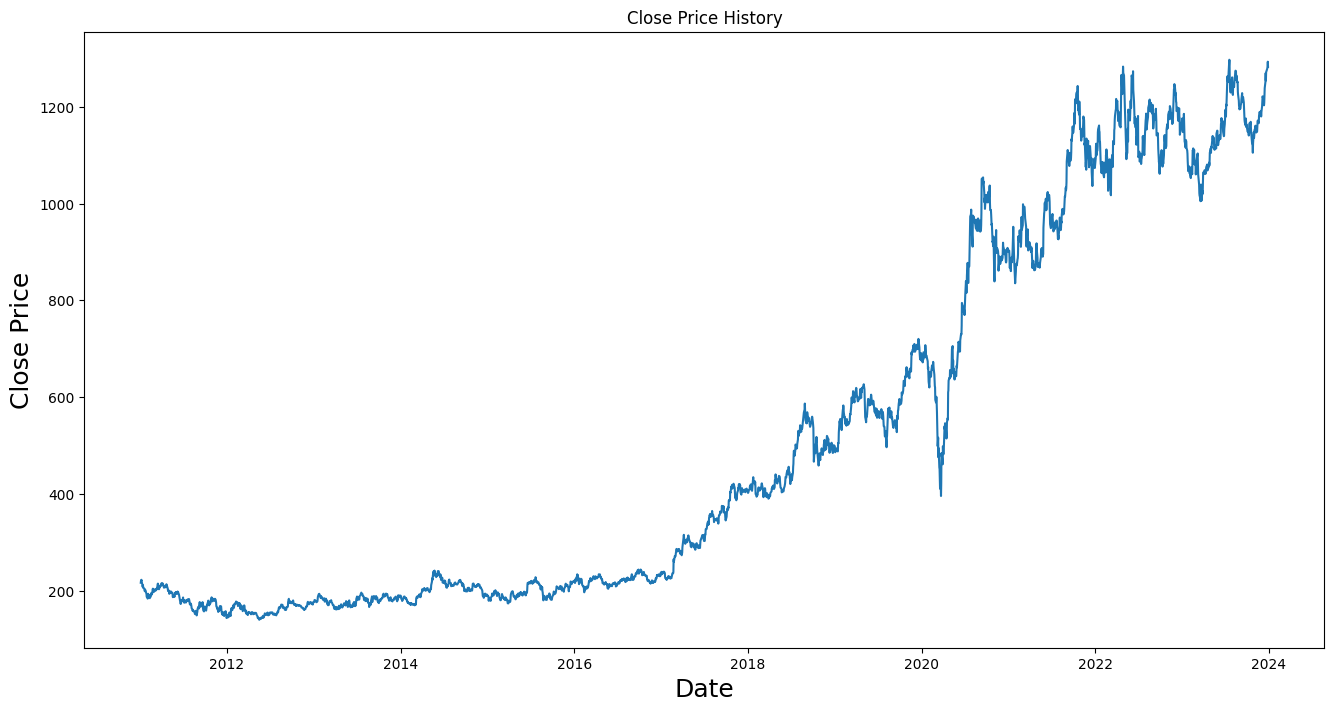

In [14]:
plt.figure(figsize=(16,8))
plt.title('Close Price History')
plt.plot(data['Date'],data['Close'])
plt.xlabel('Date',fontsize=18)
plt.ylabel('Close Price',fontsize=18)
plt.show()

In [15]:
data.to_csv('data.csv')
data_train.to_csv('training.csv')
data_test.to_csv('test.csv')

In [16]:
data_test.columns

MultiIndex([(  'Date',            ''),
            ( 'Close', 'RELIANCE.NS'),
            (  'High', 'RELIANCE.NS'),
            (   'Low', 'RELIANCE.NS'),
            (  'Open', 'RELIANCE.NS'),
            ('Volume', 'RELIANCE.NS')],
           names=['Price', 'Ticker'])

In [17]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [18]:
data_train_scaled = scaler.fit_transform(data_train['Close'])

In [19]:
x =[]
y =[]
for i in range(100,data_train_scaled.shape[0]):
  x.append(data_train_scaled[i-100:i])
  y.append(data_train_scaled[i,0])

In [20]:
x,y = np.array(x),np.array(y)

In [21]:
from keras.layers import Dense,Dropout,LSTM
from keras.models import Sequential

In [22]:
model = Sequential()
model.add(LSTM(units=50,activation='relu',return_sequences=True,input_shape=(x.shape[1],1)))
model.add(Dropout(0.20))

model.add(LSTM(units=60,activation='relu',return_sequences=True))
model.add(Dropout(0.30))

model.add(LSTM(units=80,activation='relu',return_sequences=True))
model.add(Dropout(0.40))

model.add(LSTM(units=120,activation='relu'))
model.add(Dropout(0.50))

model.add(Dense(units=1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [23]:
model.compile(optimizer='adam',loss='mean_squared_error')

In [24]:
model.fit(x,y,epochs=50,batch_size=32,verbose=1)

Epoch 1/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 26s 246ms/step - loss: 0.0197
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 21s 255ms/step - loss: 0.0046
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 20s 265ms/step - loss: 0.0043
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 20s 267ms/step - loss: 0.0035
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 20s 261ms/step - loss: 0.0035
Epoch 6/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 19s 244ms/step - loss: 0.0031
Epoch 7/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 22s 264ms/step - loss: 0.0037
Epoch 8/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 246ms/step - loss: 0.0035
Epoch 9/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 19s 264ms/step - loss: 0.0036
Epoch 10/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 247ms/step - loss: 0.0038
Epoch 11/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 20s 276ms/step - loss: 0.0029
Epoch 12/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 21s 284ms/step - loss: 0.0032
Epoch 13/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 29s 395ms/step - loss: 0.0031
Epoch 14/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 33s 282ms/step - loss: 0.0030
Epoch 15/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 22s 

In [25]:
pas_100_days = data_train.tail(100)

In [26]:
data_test = pd.concat([pas_100_days,data_test],ignore_index=True)

In [27]:
data_test

Price,Date,Close,High,Low,Open,Volume
Ticker,,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
0,2020-08-11,967.531555,979.411466,952.364256,967.984974,46828306
1,2020-08-12,964.720337,972.610094,955.288981,961.727691,30264617
2,2020-08-13,962.203857,969.844148,956.739988,964.901760,24830322
3,2020-08-14,958.463074,978.051280,947.331323,962.430561,33224635
4,2020-08-17,948.283569,954.472873,938.648141,954.472873,30979066
...,...,...,...,...,...,...
836,2023-12-22,1273.102173,1280.968874,1264.466020,1270.397218,16541784
837,2023-12-26,1279.554443,1286.453333,1271.935784,1274.566338,7465664
838,2023-12-27,1283.922119,1290.399082,1277.097630,1281.514887,9204156


In [28]:
data_test_scaled = scaler.fit_transform(data_test['Close'])

In [29]:
x =[]
y =[]
for i in range(100,data_test_scaled.shape[0]):
  x.append(data_test_scaled[i-100:i])
  y.append(data_test_scaled[i,0])
x,y = np.array(x),np.array(y)

In [30]:
y_predict = model.predict(x)

24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step


In [31]:
scale = 1/scaler.scale_

In [32]:
y_predict = y_predict*scale
y = y*scale

In [33]:
from sklearn.metrics import mean_squared_error

score = mean_squared_error(y, y_predict)
print(f"Mean Squared Error: {score}")

Mean Squared Error: 1471.3778741949784


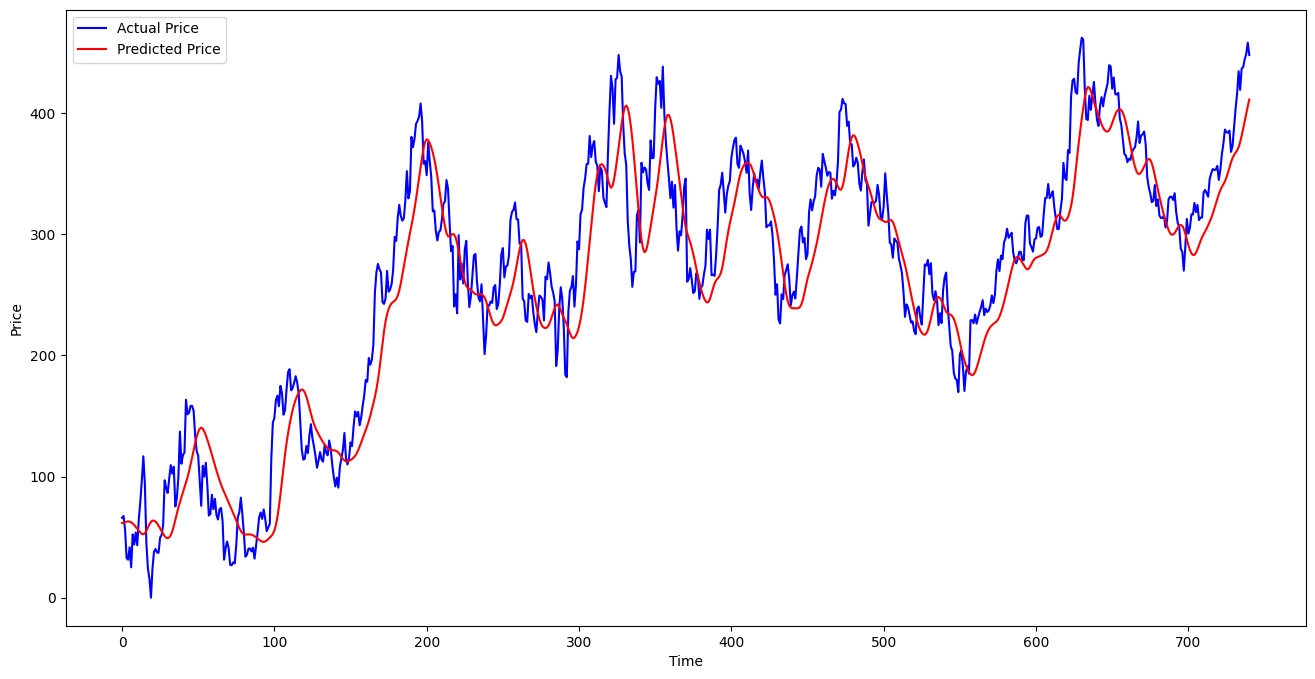

In [34]:
plt.figure(figsize=(16,8))
plt.plot(y,color='blue',label='Actual Price')
plt.plot(y_predict,color='red',label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [35]:
y_predict_trend = [1 if y_predict[i+5] > y_predict[i] else 0 for i in range(len(y_predict) - 5)]

In [36]:
y_original_trend = [1 if y[i+5] > y[i] else 0 for i in range(len(y) - 5)]

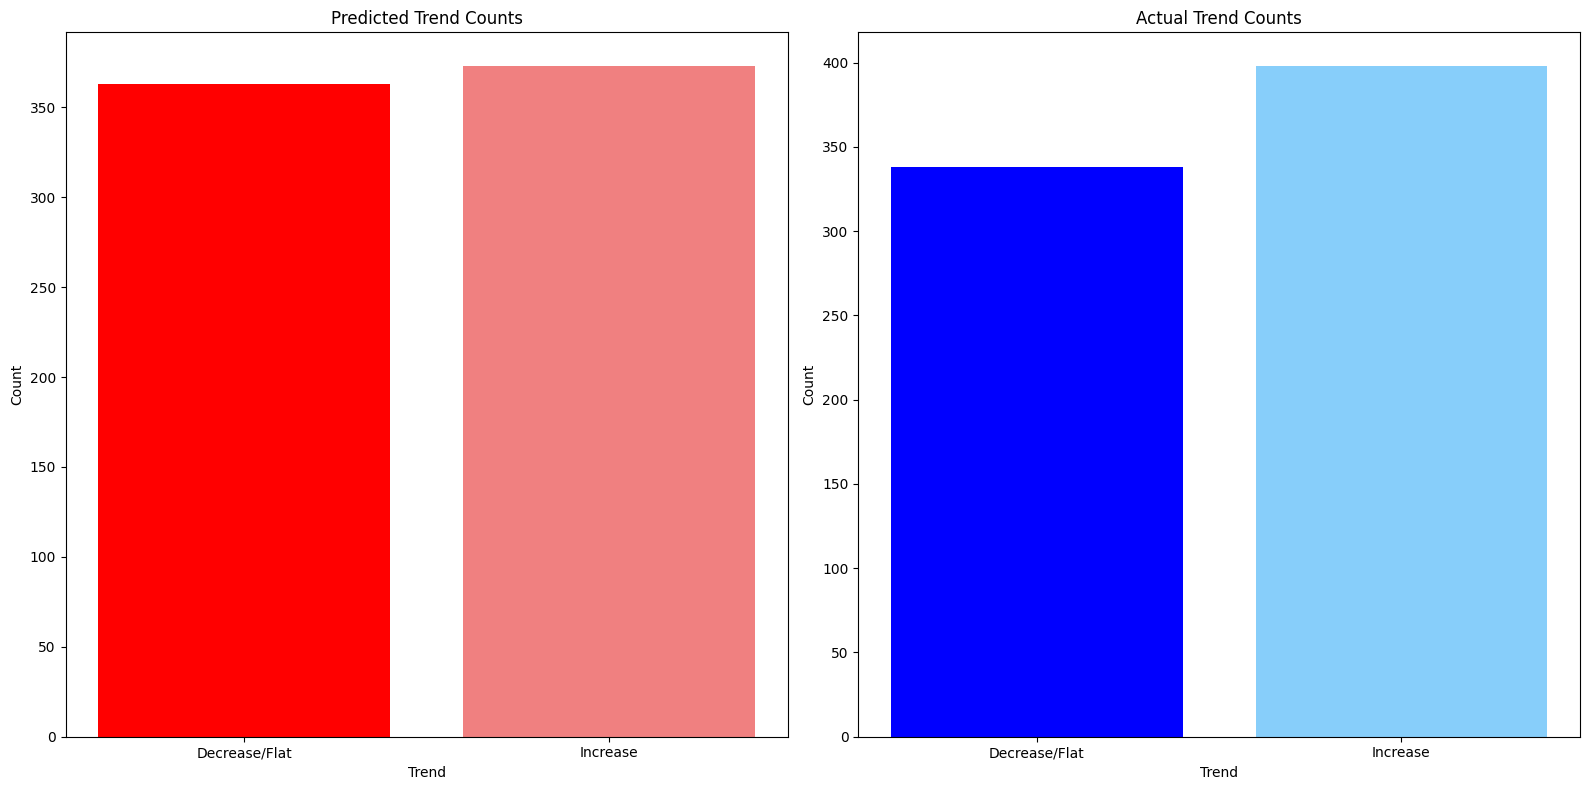

In [37]:
import matplotlib.pyplot as plt
from collections import Counter

# Count the occurrences of 0s and 1s for predicted trend
predicted_counts = Counter(y_predict_trend)
predicted_labels = list(predicted_counts.keys())
predicted_values = list(predicted_counts.values())

# Count the occurrences of 0s and 1s for original trend
original_counts = Counter(y_original_trend)
original_labels = list(original_counts.keys())
original_values = list(original_counts.values())

plt.figure(figsize=(16, 8))

# Subplot for Predicted Trend
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.bar(['Decrease/Flat', 'Increase'], [predicted_counts.get(0, 0), predicted_counts.get(1, 0)], color=['red', 'lightcoral'])
plt.title('Predicted Trend Counts')
plt.xlabel('Trend')
plt.ylabel('Count')

# Subplot for Original Trend
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.bar(['Decrease/Flat', 'Increase'], [original_counts.get(0, 0), original_counts.get(1, 0)], color=['blue', 'lightskyblue'])
plt.title('Actual Trend Counts')
plt.xlabel('Trend')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [38]:
from sklearn.metrics import f1_score
score  = f1_score(y_original_trend,y_predict_trend)
print(score)

0.5758754863813229


Initial Capital: ₹1,000,000.00
Final Capital: ₹1,307,342.17
Total Return: 30.73%


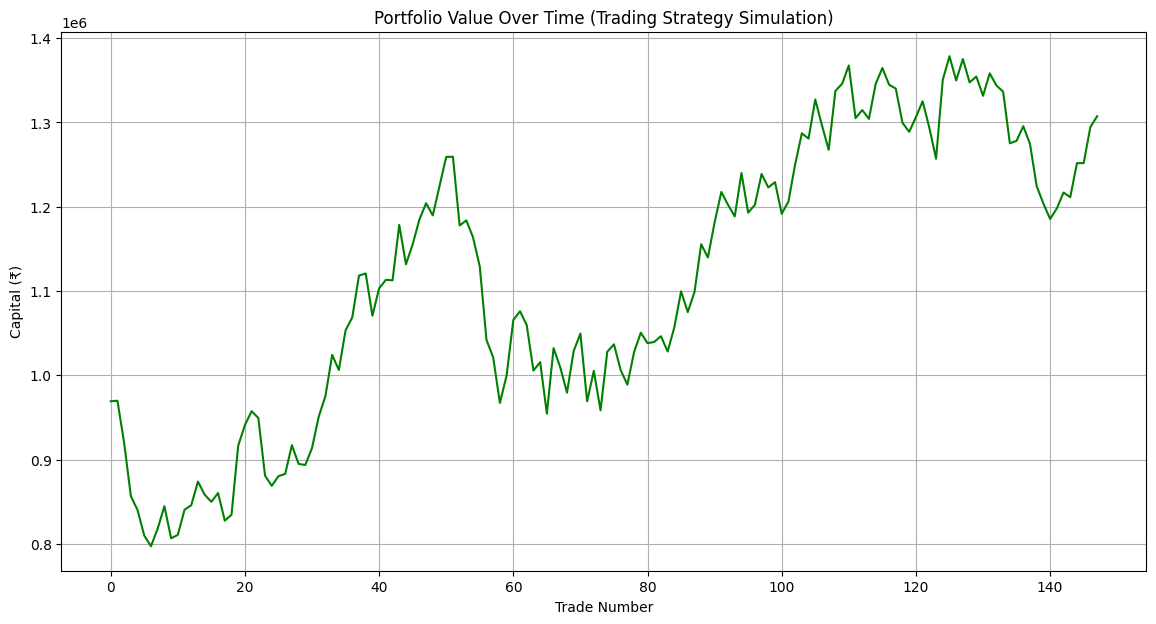

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


initial_capital = 1_000_000
capital = initial_capital
portfolio_values = [] # To store capital after each completed trade
skip_signals = 0 # Counter for days to skip new signals during holding period

# Define column names for clarity
open_col = ('Open', 'RELIANCE.NS')
close_col = ('Close', 'RELIANCE.NS')

# Iterate through the predicted trends to simulate trading
# y_predict_trend[j] is the signal generated on Day T, where Day T corresponds
# to data_test.iloc[100 + j] in the data_test DataFrame.
for j in range(len(y_predict_trend)):
    # If we are in a holding period, skip new signals
    if skip_signals > 0:
        skip_signals -= 1
        continue

    signal = y_predict_trend[j] # Get the signal (1 for long, 0 for short)

    # Map the signal index 'j' to the corresponding day in the data_test DataFrame.
    # The first 'y' and 'y_predict' elements correspond to data_test.iloc[100].
    # So, signal 'j' is effectively generated at data_test index '100 + j'.
    idx_signal_day_T = 100 + j

    # Ensure we have enough future data for a full 5-day trade (entry on T+1, exit on T+5)
    # This means we need data_test indices up to `idx_signal_day_T + 5`
    if idx_signal_day_T + 5 >= len(data_test):
        break # Not enough data for a complete trade, stop simulation

    # Determine entry and exit points
    idx_entry_day_T_plus_1 = idx_signal_day_T + 1
    idx_exit_day_T_plus_5 = idx_signal_day_T + 5

    # Get open and close prices for the trade
    entry_price = data_test[open_col].iloc[idx_entry_day_T_plus_1]
    exit_price = data_test[close_col].iloc[idx_exit_day_T_plus_5]

    # Calculate profit/loss for the trade
    trade_profit_loss_abs = 0
    if entry_price != 0:
        if signal == 1: # Go Long: Buy at entry_price, sell at exit_price
            trade_profit_loss_abs = (exit_price - entry_price)
        elif signal == 0: # Go Short: Sell at entry_price, buy back at exit_price
            trade_profit_loss_abs = (entry_price - exit_price)

        # Update capital based on percentage change from this trade
        percentage_change = trade_profit_loss_abs / entry_price
        capital += capital * percentage_change

    portfolio_values.append(capital)

    # Set skip_signals for the holding period.
    # If signal 'j' was used, we need to ignore signals 'j+1' to 'j+4' (4 signals).
    # The loop will then process 'j+5' next when skip_signals reaches 0.
    skip_signals = 4

print(f"Initial Capital: ₹{initial_capital:,.2f}")
print(f"Final Capital: ₹{capital:,.2f}")
print(f"Total Return: {((capital - initial_capital) / initial_capital * 100):.2f}%")


plt.figure(figsize=(14, 7))
plt.plot(portfolio_values, color='green')
plt.title('Portfolio Value Over Time (Trading Strategy Simulation)')
plt.xlabel('Trade Number')
plt.ylabel('Capital (₹)')
plt.grid(True)
plt.show()

In [40]:
portfolio = pd.Series(portfolio_values)
portfolio_returns = portfolio.pct_change().dropna()
annual_risk_free_rate = 0.05
# Converting annualized risk-free rate to daily risk-free rate (assuming 252 trading days in a year)
daily_risk_free_rate = (1 + annual_risk_free_rate)**(1/252) - 1

# Calculate excess daily returns
excess_daily_returns = portfolio_returns - daily_risk_free_rate

# Calculate the standard deviation of excess daily returns
std_dev_excess_returns = excess_daily_returns.std()

# Calculate the daily Sharpe Ratio
daily_sharpe_ratio = excess_daily_returns.mean() / std_dev_excess_returns

# Annualize the Sharpe Ratio (assuming 252 trading days)
annualized_sharpe_ratio = daily_sharpe_ratio * np.sqrt(252)

print(f"Annualized Sharpe Ratio: {annualized_sharpe_ratio:.4f}")

Annualized Sharpe Ratio: 1.1519
